In [1]:
%pip install scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import pyarrow.parquet as pq

df_votes = pq.read_table("./data/votes.parquet").to_pandas()
print(" Votes dataset loaded successfully.")
df_conversations = pq.read_table("./data/conversations.parquet").to_pandas()
print(" Conversations dataset loaded successfully.")
df_reactions = pq.read_table("./data/reactions.parquet").to_pandas()
print(" Reactions dataset loaded successfully.")

 Votes dataset loaded successfully.
 Conversations dataset loaded successfully.
 Reactions dataset loaded successfully.


In [3]:
df_conversations[df_conversations["conversation_pair_id"] == '8a15faf5c5374cc1bbbc84426a8bc0e6-e4ed6e033a844c9eb5eab207533896b6']

,id,timestamp,model_a_name,model_b_name,conversation_a,conversation_b,conv_turns,conversation_pair_id,conv_a_id,conv_b_id,...,categories,languages,total_conv_a_output_tokens,total_conv_b_output_tokens,model_a_total_params,model_b_total_params,model_a_active_params,model_b_active_params,total_conv_a_kwh,total_conv_b_kwh
344785,429872,2025-04-22 17:39:07.305130,gemma-3-4b,c4ai-command-r-08-2024,[{'content': 'J'ai lu quelque part (je ne sais...,[{'content': 'J'ai lu quelque part (je ne sais...,11,8a15faf5c5374cc1bbbc84426a8bc0e6-e4ed6e033a844...,8a15faf5c5374cc1bbbc84426a8bc0e6,e4ed6e033a844c9eb5eab207533896b6,...,[Natural Science & Formal Science & Technology...,[fr],6305,4906,4.0,NaN,4.0,NaN,0.000532,0.0


In [4]:
df_votes['conversation_pair_id'][1]

'8a15faf5c5374cc1bbbc84426a8bc0e6-e4ed6e033a844c9eb5eab207533896b6'

In [5]:
df_votes.columns.to_list()

['id',
 'timestamp',
 'model_a_name',
 'model_b_name',
 'model_pair_name',
 'chosen_model_name',
 'opening_msg',
 'both_equal',
 'conversation_a',
 'conversation_b',
 'conv_turns',
 'selected_category',
 'is_unedited_prompt',
 'conversation_pair_id',
 'session_hash',
 'visitor_id',
 'conv_comments_a',
 'conv_comments_b',
 'conv_useful_a',
 'conv_useful_b',
 'conv_creative_a',
 'conv_creative_b',
 'conv_clear_formatting_a',
 'conv_clear_formatting_b',
 'conv_incorrect_a',
 'conv_incorrect_b',
 'conv_superficial_a',
 'conv_superficial_b',
 'conv_instructions_not_followed_a',
 'conv_instructions_not_followed_b',
 'system_prompt_b',
 'system_prompt_a',
 'conv_complete_a',
 'conv_complete_b']

<h2>Biais de longueur</h2>

In [6]:
col_int = ['conversation_pair_id',
 'model_a_name',
 'model_b_name',
 'chosen_model_name',
 'opening_msg',
 'both_equal',
 'conversation_a',
 'conversation_b',
 'conv_turns',
 'session_hash',
 'visitor_id',
 'system_prompt_b',
 'system_prompt_a']

df_votes_int = df_votes[col_int]

In [7]:
df_conv_filtre = df_conversations[["conversation_pair_id", "total_conv_a_output_tokens", "total_conv_b_output_tokens"]]

df_merge = df_votes_int.merge(df_conv_filtre, left_on="conversation_pair_id", right_on="conversation_pair_id", how="left")

df_merge.head()

,conversation_pair_id,model_a_name,model_b_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,conv_turns,session_hash,visitor_id,system_prompt_b,system_prompt_a,total_conv_a_output_tokens,total_conv_b_output_tokens
0,2bd61e83f28f4b4b8194d818f4a04505-d3d7b1a7c0944...,gemini-2.5-flash,grok-4-fast,None,crée des cartes types dixit sur le thème des m...,True,[{'content': 'crée des cartes types dixit sur ...,[{'content': 'crée des cartes types dixit sur ...,2,bfsfi12kqtn,fc56866e083476414e83d6f9e3c7f278,None,None,2945.0,2085.0
1,8a15faf5c5374cc1bbbc84426a8bc0e6-e4ed6e033a844...,gemma-3-4b,c4ai-command-r-08-2024,gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,False,[{'content': 'J'ai lu quelque part (je ne sais...,[{'content': 'J'ai lu quelque part (je ne sais...,11,ckjk99qfvl8,9b818e46ca74b660146b4a05075e56e7,None,None,6305.0,4906.0
2,02a1beb885d6437b9aaf86ca2150cada-72440d05cd4b4...,phi-4,llama-3.1-405b,None,créer un texte sur le degrés d'intégration des...,True,[{'content': 'créer un texte sur le degrés d'i...,[{'content': 'créer un texte sur le degrés d'i...,1,5cnmcat72jc,c33091ad79ff386d618d4f14cdecd242,None,None,1139.0,767.0
3,573f0e72a1224bf593b4a3e99ec84cc1-a38898e3fede4...,phi-4,gemma-3-27b,gemma-3-27b,Coucou,False,"[{'content': 'Coucou ', 'metadata': None, 'rea...","[{'content': 'Coucou ', 'metadata': None, 'rea...",1,ch2oclz234w,e85c39f65f08cd06257f57c8f5035181,None,None,11.0,26.0
4,765ed4394730412080786719f230d9f4-c4ea6d3ea0724...,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,False,[{'content': 'Tu es un assistant IA serviable ...,[{'content': 'Je souhaite élaborer des routine...,1,lgq16bamoz,1c921335a2cc49ccaa0a54d4cd92faa1,,Tu es un assistant IA serviable et bienveillan...,352.0,724.0


In [8]:
df_nan = df_merge[(df_merge['total_conv_a_output_tokens'] == 0) | (df_merge['total_conv_b_output_tokens'] == 0)]

df_without_null = df_merge[(df_merge['total_conv_a_output_tokens'] != 0) & (df_merge['total_conv_b_output_tokens'] != 0)]

In [9]:
df_without_null = df_without_null.copy()
df_without_null["token_diff_a_minus_b"] = (
    df_without_null["total_conv_a_output_tokens"] - df_without_null["total_conv_b_output_tokens"]
)

df_corr = df_without_null[
    (df_without_null["chosen_model_name"] == df_without_null["model_a_name"])
    | (df_without_null["chosen_model_name"] == df_without_null["model_b_name"])
][ ["token_diff_a_minus_b", "chosen_model_name", "model_a_name"] ].copy()

df_corr["chosen_a"] = (df_corr["chosen_model_name"] == df_corr["model_a_name"]).astype(int)

correlation = df_corr["token_diff_a_minus_b"].corr(df_corr["chosen_a"])

print(f"Corrélation (diff tokens A-B vs choix de A): {correlation:.4f}")
print(f"Nombre d'observations utilisées: {len(df_corr)}")

Corrélation (diff tokens A-B vs choix de A): 0.1007
Nombre d'observations utilisées: 102497


Il y a un biais de longueur existant mais modéré. La faible valeur indique que sur les échantillons observés, une longueur plus importante de la réponse peut être favorisée, mais la relativement faible valeur montre que c'est loin d'être une raison prédominante.

In [10]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

df_model = df_votes.merge(
    df_conv_filtre, on="conversation_pair_id", how="left"
).copy()

# Garder uniquement les duels avec choix explicite A ou B
df_model = df_model[
    (df_model["chosen_model_name"] == df_model["model_a_name"])
    | (df_model["chosen_model_name"] == df_model["model_b_name"])
]

# Variable d'intérêt
df_model["token_diff_a_minus_b"] = (
    df_model["total_conv_a_output_tokens"] - df_model["total_conv_b_output_tokens"]
)

# Cible
df_model["chosen_a"] = (
    df_model["chosen_model_name"] == df_model["model_a_name"]
).astype(int)

# Covariables numériques générales
df_model["opening_msg_len"] = df_model["opening_msg"].fillna("").str.len()
df_model["system_prompt_a_len"] = df_model["system_prompt_a"].fillna("").str.len()
df_model["system_prompt_b_len"] = df_model["system_prompt_b"].fillna("").str.len()
df_model["timestamp"] = pd.to_datetime(df_model["timestamp"], errors="coerce")
df_model["hour"] = df_model["timestamp"].dt.hour
df_model["dayofweek"] = df_model["timestamp"].dt.dayofweek
df_model["is_unedited_prompt_num"] = pd.to_numeric(
    df_model["is_unedited_prompt"], errors="coerce"
)

# Différences A-B sur signaux conversationnels potentiellement utiles
paired_metrics = [
    "conv_useful",
    "conv_creative",
    "conv_clear_formatting",
    "conv_incorrect",
    "conv_superficial",
    "conv_instructions_not_followed",
    "conv_complete",
]
for metric in paired_metrics:
    col_a = f"{metric}_a"
    col_b = f"{metric}_b"
    if col_a in df_model.columns and col_b in df_model.columns:
        a_num = pd.to_numeric(df_model[col_a].astype("float"), errors="coerce")
        b_num = pd.to_numeric(df_model[col_b].astype("float"), errors="coerce")
        df_model[f"{metric}_diff_a_minus_b"] = a_num - b_num

feature_num = [
    "token_diff_a_minus_b",
    "conv_turns",
    "opening_msg_len",
    "system_prompt_a_len",
    "system_prompt_b_len",
    "hour",
    "dayofweek",
    "is_unedited_prompt_num",
] + [
    c for c in df_model.columns if c.endswith("_diff_a_minus_b")
 and c != "token_diff_a_minus_b"
]

feature_cat = ["selected_category", "model_a_name", "model_b_name"]

X = df_model[feature_num + feature_cat]
y = df_model["chosen_a"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, feature_num),
        ("cat", cat_pipe, feature_cat),
    ]
)

logit = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=3000, solver="saga")),
    ]
)

logit.fit(X_train, y_train)
y_pred = logit.predict(X_test)
y_proba = logit.predict_proba(X_test)[:, 1]

feature_names = logit.named_steps["preprocess"].get_feature_names_out()
coef_all = logit.named_steps["model"].coef_[0]
coef_token_diff = coef_all[np.where(feature_names == "num__token_diff_a_minus_b")[0][0]]

coef_table = pd.DataFrame({"feature": feature_names, "coef": coef_all})
top_coef = coef_table.reindex(coef_table["coef"].abs().sort_values(ascending=False).index).head(10)

print(f"Coefficient ajusté token_diff_a_minus_b: {coef_token_diff:.6f}")
print(f"Odds ratio ajusté pour +100 tokens: {float(np.exp(100 * coef_token_diff)):.4f}")
print(f"Accuracy test: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC test: {roc_auc_score(y_test, y_proba):.4f}")
print(f"N observations: {len(df_model)}")
print("\nTop 10 coefficients (|coef|):")
print(top_coef.to_string(index=False))

Coefficient ajusté token_diff_a_minus_b: 0.000228
Odds ratio ajusté pour +100 tokens: 1.0231
Accuracy test: 0.5961
ROC-AUC test: 0.6113
N observations: 104566

Top 10 coefficients (|coef|):
                                           feature      coef
                          num__system_prompt_b_len  0.004627
                          num__system_prompt_a_len -0.003987
                 num__conv_complete_diff_a_minus_b  0.003516
         num__conv_clear_formatting_diff_a_minus_b  0.002901
                   num__conv_useful_diff_a_minus_b  0.002528
              num__conv_superficial_diff_a_minus_b -0.001872
                                         num__hour  0.001326
                num__conv_incorrect_diff_a_minus_b -0.001004
                 num__conv_creative_diff_a_minus_b  0.000888
num__conv_instructions_not_followed_diff_a_minus_b -0.000832


/Users/hugues/.pyenv/versions/td/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [11]:
from sklearn.linear_model import LogisticRegression

# Échantillon commun pour comparer "avant" vs "après correction"
df_bt = df_votes.merge(df_conv_filtre, on="conversation_pair_id", how="left").copy()
df_bt = df_bt[
    (df_bt["chosen_model_name"] == df_bt["model_a_name"])
    | (df_bt["chosen_model_name"] == df_bt["model_b_name"])
]
df_bt = df_bt.dropna(subset=["total_conv_a_output_tokens", "total_conv_b_output_tokens", "model_a_name", "model_b_name"]).copy()
df_bt["token_diff_a_minus_b"] = df_bt["total_conv_a_output_tokens"] - df_bt["total_conv_b_output_tokens"]
df_bt["chosen_a"] = (df_bt["chosen_model_name"] == df_bt["model_a_name"]).astype(int)

models = sorted(set(df_bt["model_a_name"]).union(set(df_bt["model_b_name"])))
ref_model = models[-1]
model_to_col = {m: i for i, m in enumerate([m for m in models if m != ref_model])}

n = len(df_bt)
p = len(models) - 1
X_bt = np.zeros((n, p), dtype=float)

idx_a = df_bt["model_a_name"].map(model_to_col)
idx_b = df_bt["model_b_name"].map(model_to_col)
rows = np.arange(n)

mask_a = idx_a.notna()
mask_b = idx_b.notna()
X_bt[rows[mask_a], idx_a[mask_a].astype(int)] = 1.0
X_bt[rows[mask_b], idx_b[mask_b].astype(int)] = -1.0

y_bt = df_bt["chosen_a"].to_numpy()

# Bradley-Terry non corrigé
bt_base = LogisticRegression(fit_intercept=False, max_iter=3000, solver="lbfgs", C=1e6)
bt_base.fit(X_bt, y_bt)

# Bradley-Terry corrigé par la différence de longueur
X_bt_corr = np.column_stack([X_bt, df_bt["token_diff_a_minus_b"].to_numpy()])
bt_corr = LogisticRegression(fit_intercept=False, max_iter=3000, solver="lbfgs", C=1e6)
bt_corr.fit(X_bt_corr, y_bt)

coef_base = bt_base.coef_[0]
coef_corr = bt_corr.coef_[0][:p]
coef_token = bt_corr.coef_[0][p]

score_base = {m: 0.0 for m in models}
score_corr = {m: 0.0 for m in models}
for m, j in model_to_col.items():
    score_base[m] = coef_base[j]
    score_corr[m] = coef_corr[j]

rank_base = pd.DataFrame(score_base.items(), columns=["model", "score_base"]).sort_values("score_base", ascending=False)
rank_base["rank_base"] = np.arange(1, len(rank_base) + 1)
rank_corr = pd.DataFrame(score_corr.items(), columns=["model", "score_corr"]).sort_values("score_corr", ascending=False)
rank_corr["rank_corr"] = np.arange(1, len(rank_corr) + 1)

rank_compare = rank_base.merge(rank_corr, on="model")
rank_compare["delta_rank"] = rank_compare["rank_base"] - rank_compare["rank_corr"]

rho_rank = rank_compare[["rank_base", "rank_corr"]].corr(method="spearman").loc["rank_base", "rank_corr"]

print(f"Coefficient correction longueur (token_diff_a_minus_b): {coef_token:.6f}")
print(f"Spearman des rangs avant/après correction: {rho_rank:.4f}")
print("\nTop modèles qui montent après correction (delta_rank > 0):")
print(
    rank_compare[rank_compare["delta_rank"] > 0]
    .sort_values("delta_rank", ascending=False)
    .head(10)
    .to_string(index=False)
)
print("\nTop modèles qui baissent après correction (delta_rank < 0):")
print(
    rank_compare[rank_compare["delta_rank"] < 0]
    .sort_values("delta_rank", ascending=True)
    .head(10)
    .to_string(index=False)
 )

Coefficient correction longueur (token_diff_a_minus_b): 0.000193
Spearman des rangs avant/après correction: 0.9779

Top modèles qui montent après correction (delta_rank > 0):
                          model  score_base  rank_base  score_corr  rank_corr  delta_rank
                claude-4-sonnet    0.282758         34    0.395166         21          13
              claude-3-7-sonnet    0.231416         38    0.323749         27          11
                 llama-maverick   -0.041080         55    0.042092         44          11
 Qwen3-Coder-480B-A35B-Instruct    0.263800         35    0.351445         25          10
                        gpt-5.3    0.316246         27    0.433341         19           8
                   mistral-saba   -0.029983         53    0.038412         45           8
                        kimi-k2    0.237647         36    0.320448         28           8
                   gpt-4.1-nano   -0.382924         75   -0.267020         67           8
               

### Synthèse (biais de longueur et classement Bradley-Terry)
- La différence de longueur (`tokens_A - tokens_B`) est positivement associée au choix de A (corrélation positive mais faible).
- En régression logistique multivariée, l’effet ajusté reste positif : +100 tokens pour A augmente ses odds d’être choisi d’environ 2 à 2,5 %.
- Le biais de longueur est donc réel, mais d’ampleur modérée au niveau individuel.
- Après correction de longueur dans le modèle Bradley-Terry, le classement global reste proche de l’original (Spearman ≈ 0,98).
- Néanmoins, certains modèles changent fortement de rang : la correction affecte surtout des cas particuliers plutôt que l’ordre global.
- Interprétation : une partie des écarts de préférence observés provient de la longueur des réponses, mais ce n’est pas le facteur dominant.

<h2>Biais de position</h2>

In [12]:
from scipy.stats import chi2_contingency
import numpy as np

def normalize_liked(series):
    s = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": "true",
        "false": "false",
        "1": "true",
        "0": "false",
        "yes": "true",
        "no": "false",
    }
    return s.map(mapping)

def chi2_position_effect(df, label="global"):
    sub = df.dropna(subset=["model_pos", "liked"]).copy()
    sub["model_pos"] = sub["model_pos"].astype(str).str.strip().str.lower()
    sub = sub[sub["model_pos"].isin(["a", "b"])]
    sub["liked_norm"] = normalize_liked(sub["liked"])

    valid = sub.dropna(subset=["liked_norm"]).copy()

    contingency = pd.crosstab(valid["model_pos"], valid["liked_norm"])
    for col in ["false", "true"]:
        if col not in contingency.columns:
            contingency[col] = 0
    contingency = contingency[["false", "true"]].reindex(["a", "b"], fill_value=0)

    n = int(contingency.to_numpy().sum())
    r, c = contingency.shape
    rate_a = contingency.loc["a", "true"] / contingency.loc["a"].sum() if contingency.loc["a"].sum() > 0 else np.nan
    rate_b = contingency.loc["b", "true"] / contingency.loc["b"].sum() if contingency.loc["b"].sum() > 0 else np.nan

    if n == 0 or (contingency.sum(axis=1) == 0).any() or (contingency.sum(axis=0) == 0).any():
        return {
            "subset": label,
            "n": n,
            "liked_rate_a": rate_a,
            "liked_rate_b": rate_b,
            "diff_a_minus_b": rate_a - rate_b if pd.notna(rate_a) and pd.notna(rate_b) else np.nan,
            "chi2": np.nan,
            "p_value": np.nan,
            "cramers_v": np.nan,
            "contingency": contingency,
            "model_pos_counts": valid["model_pos"].value_counts(dropna=False),
            "liked_raw_top": sub["liked"].astype(str).str.lower().value_counts(dropna=False).head(5),
        }

    chi2, p_value, dof, expected = chi2_contingency(contingency)
    cramer_v = np.sqrt(chi2 / (n * (min(r, c) - 1))) if min(r, c) > 1 else np.nan

    return {
        "subset": label,
        "n": n,
        "liked_rate_a": rate_a,
        "liked_rate_b": rate_b,
        "diff_a_minus_b": rate_a - rate_b if pd.notna(rate_a) and pd.notna(rate_b) else np.nan,
        "chi2": chi2,
        "p_value": p_value,
        "cramers_v": cramer_v,
        "contingency": contingency,
        "model_pos_counts": valid["model_pos"].value_counts(dropna=False),
        "liked_raw_top": sub["liked"].astype(str).str.lower().value_counts(dropna=False).head(5),
    }

results = [chi2_position_effect(df_reactions, label="global")]

for qualif in ["creative", "useful", "incorrect"]:
    if qualif in df_reactions.columns:
        df_q = df_reactions[df_reactions[qualif] == True]
        results.append(chi2_position_effect(df_q, label=qualif))
    else:
        print(f"Colonne absente dans df_reactions: {qualif}")

summary = pd.DataFrame([{k: v for k, v in r.items() if k not in ["contingency", "model_pos_counts", "liked_raw_top"]} for r in results])
summary["significatif_5pct"] = summary["p_value"] < 0.05

print("Résumé des tests chi-deux (liked ~ model_pos):")
display(summary)

for r in results:
    print(f"\n--- Distribution model_pos (valid liked): {r['subset']} ---")
    display(r["model_pos_counts"].rename("count").to_frame())
    print(f"--- Contingence: {r['subset']} ---")
    display(r["contingency"])

    print(f"--- Top valeurs brutes de liked: {r['subset']} ---")
    display(r["liked_raw_top"].rename("count").to_frame())

Résumé des tests chi-deux (liked ~ model_pos):


,subset,n,liked_rate_a,liked_rate_b,diff_a_minus_b,chi2,p_value,cramers_v,significatif_5pct
0,global,94294,0.674149,0.683345,-0.009196,9.099749,0.002556,0.009824,True
1,creative,6354,0.998041,0.999088,-0.001047,0.601189,0.438125,0.009727,False
2,useful,22376,0.999165,0.999052,0.000113,0.003479,0.952963,0.000394,False
3,incorrect,10240,0.000000,0.000000,0.000000,NaN,NaN,NaN,False



--- Distribution model_pos (valid liked): global ---


,count
model_pos,
b,47607
a,46687


--- Contingence: global ---


...

,count
model_pos,
b,5125
a,5115


--- Contingence: incorrect ---


liked_norm,false,true
model_pos,,
a,5115,0
b,5125,0


--- Top valeurs brutes de liked: incorrect ---


,count
liked,
false,10240


### Synthèse (biais de position)
- Le test du chi-deux global (`liked ~ model_pos`) est significatif : $\chi^2=9.10$, $p=0.0026$ (N=94 294).
- L'effet de position reste toutefois très faible en taille d’effet (Cramér’s $V=0.0098$).
- Taux de réactions positives : position A = 67.41 %, position B = 68.33 % (écart = -0.92 point).
- Pour les sous-ensembles `creative` et `useful`, l’effet n’est pas significatif (p=0.438 et p=0.953).
- Pour `incorrect`, le test est non identifiable car `liked` est constant (100 % `false`).
- Conclusion : il existe un biais de position détectable globalement, mais son impact pratique est faible.

## Conclusion — protocole d’annotation compar:IA v2
**Objectif** : réduire simultanément les biais de position, de longueur et de sélection, avec contrainte produit $\Delta$ abandon $\leq 15\%$ (vs version actuelle).

### 1) Design d’interface (réduction des biais sans coût cognitif fort)
- **Masquage systématique des identités** jusqu’au vote, comme dans Chatbot Arena, pour limiter les effets de marque et d’attentes utilisateur (Chiang et al., 2024 ; LMSYS Arena blog, 2023).
- **Randomisation 50/50 de la position A/B** à chaque duel + journalisation de `model_pos` pour correction ex post des biais de position (Zheng et al., 2023 signale explicitement les biais de position/verbosity en jugement pairwise).
- **Affichage progressif des réponses longues** (aperçu + “voir plus”) symétrique pour A et B, afin de réduire l’avantage perceptif des réponses longues sans tronquer l’information.
- **Vote en 1 clic + option “égalité / les deux mauvais”** pour garder une friction minimale (préserve le taux de complétion).

### 2) Échantillonnage et sélection des matchs (biais de sélection)
- **Plan mixte de sampling** : 70% paires informatives (incertitude élevée de rating) + 30% paires d’exploration uniforme pour couvrir tous les modèles.
- **Quota dynamique par langue / catégorie de prompt** pour éviter qu’un sous-groupe d’utilisateurs domine le leaderboard (Chiang et al., 2024 insiste sur la diversité des prompts crowdsourcés).
- **Limite de répétition par session** (pas de rematch immédiat même paire) pour réduire les dépendances comportementales.

### 3) Modèle statistique de ranking corrigé
- Estimer le score modèle avec un **Bradley-Terry logistique** incluant covariables :
  $$P(A\succ B)=\sigma\left((\theta_A-\theta_B)+\beta_{pos}\,I[A\text{ à gauche}]+\beta_{len}(len_A-len_B)+\gamma^\top z\right)$$
- `z` inclut au minimum : langue, catégorie, longueur du prompt, tour de conversation.
- Publier **deux classements** : brut et corrigé (transparence méthodologique), pratique cohérente avec l’esprit “arena + robustesse statistique” (Chiang et al., 2024).

### 4) Garde-fous produit (contrainte abandon ≤ 15%)
- **A/B test séquentiel** : v1 (contrôle) vs v2 (protocole proposé).
- KPI principal : `abandon_rate` (session sans vote). Condition d’acceptation :
  $$\frac{abandon_{v2}-abandon_{v1}}{abandon_{v1}} \le 0.15$$
- KPI secondaires : temps médian au vote, nombre de tours avant vote, taux d’égalité.
- **Rollout progressif** (10% → 25% → 50% → 100%) avec arrêt automatique si dépassement du seuil de 15%.

### 5) Pourquoi ce protocole est crédible
- Le cadre pairwise anonyme + randomisé est validé à grande échelle par Chatbot Arena pour produire des préférences exploitables (Chiang et al., 2024).
- Les biais de **position** et de **verbosity/longueur** sont documentés dans la littérature arena/LLM-judge, et motivent l’ajout explicite de covariables et de randomisation (Zheng et al., 2023).
- Le compromis UX (vote simple, changements invisibles côté effort) vise précisément à contrôler l’abandon tout en améliorant la validité des annotations.

**Références (arena)**
- Chiang, W.-L. et al. (2024). *Chatbot Arena: An Open Platform for Evaluating LLMs by Human Preference*. arXiv:2403.04132.
- Zheng, L. et al. (2023). *Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena*. arXiv:2306.05685.
- LMSYS (2023). *Chatbot Arena: Benchmarking LLMs in the Wild with Elo Ratings* (blog technique).

# Partie 8 : Validité de construit

## 1. Introduction

La validité de construit du label `creative` dans compar:IA doit être vérifiée pour s'assurer qu'il mesure bien la créativité réelle, et non des biais comme la longueur, le style ou la clarté rédactionnelle. Nous allons donc procéder à des tests de validité convergente et discriminante, puis discuter des limites théoriques du jugement humain de la créativité.

## 2. Validité convergente

Nous testons si `creative` corrèle positivement avec des métriques objectives de créativité :
- Diversité lexicale (MATTR)
- Rareté des n-grammes
- Distance d'embedding (SBERT)


--- Exemple créatif ---
Réponse: C'est une excellente initiative. Le tennis est un sport unique qui demande des efforts **explosifs (sprints, smashes)** mélangés à de l'**endurance (des matchs pouvant durer plusieurs heures)**. Pour ...
MATTR: 0.877

--- Exemple créatif ---
Réponse: Super ! Voici une proposition d'exposé de 5 minutes sur les fourmis, adaptée à un élève de 6ème. J'ai inclus des idées pour la structure, le contenu et des astuces pour rendre ta présentation plus cap...
MATTR: 0.850

--- Exemple créatif ---
Réponse: Voici 10 noms plus aspirationnels et moins littéraux pour un blog architecture & voyage :

| Nom du Blog | Justification |
|---|---|
| Traces & Perspectives | Évoque l'histoire, le futur et la vision ...
MATTR: 0.728
Corrélation creative/MATTR : 0.052


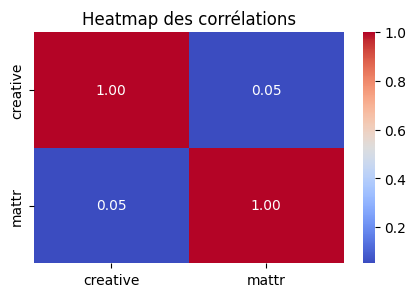

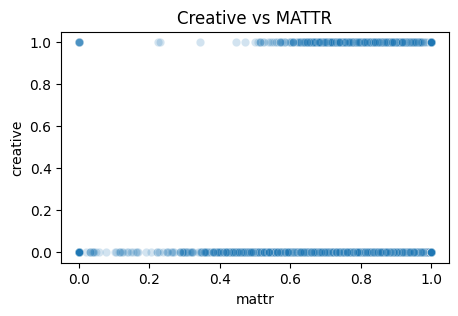

In [21]:
# 8.1 — Validité convergente : corrélations avec des métriques de créativité

import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. MATTR (diversité lexicale) ---
def mattr(text, window=50):
    tokens = str(text).split()
    if len(tokens) < window:
        return len(set(tokens)) / max(1, len(tokens))
    scores = []
    for i in range(len(tokens) - window + 1):
        window_tokens = tokens[i:i+window]
        scores.append(len(set(window_tokens)) / window)
    return np.mean(scores)

df_reactions['mattr'] = df_reactions['response_content'].apply(lambda x: mattr(x, window=50))

ex_crea = df_reactions[df_reactions['creative'] == 1].sample(3, random_state=42) if (df_reactions['creative'] == 1).sum() > 3 else df_reactions[df_reactions['creative'] == 1]
for idx, row in ex_crea.iterrows():
    print(f"\n--- Exemple créatif ---\nRéponse: {row['response_content'][:200]}...")
    print(f"MATTR: {row['mattr']:.3f}")

cor_mattr = df_reactions[['creative', 'mattr']].corr().iloc[0,1]
print(f"Corrélation creative/MATTR : {cor_mattr:.3f}")

metrics = ['creative', 'mattr']
corr_matrix = df_reactions[metrics].corr()
plt.figure(figsize=(5,3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap des corrélations')
plt.show()

plt.figure(figsize=(5,3))
sns.scatterplot(x='mattr', y='creative', data=df_reactions, alpha=0.2)
plt.title('Creative vs MATTR')
plt.show()

## 3. Validité discriminante

Nous vérifions que `creative` ne corrèle pas avec des dimensions non créatives :
- Longueur de la réponse
- Clarté du formatage
- Correction factuelle

Corrélation creative/longueur : 0.052
Corrélation creative/clear_formatting : 0.122
Corrélation creative/incorrect : -0.094
Corrélation creative/complete : 0.108


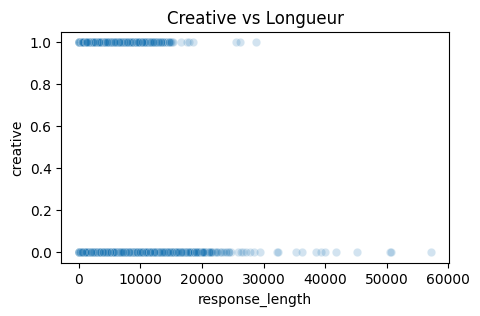

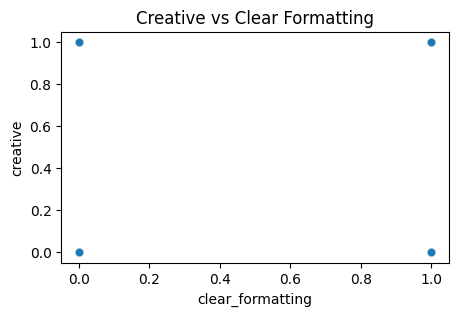

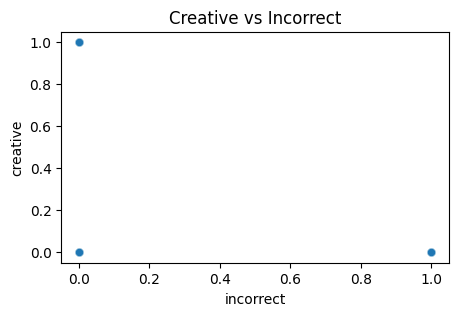

In [22]:
# 8.2 — Validité discriminante : creative ne doit pas corréler avec des dimensions non créatives

# Corrélations discriminantes
cor_length = df_reactions[['creative', 'response_length']].corr().iloc[0,1]
cor_format = df_reactions[['creative', 'clear_formatting']].corr().iloc[0,1] if 'clear_formatting' in df_reactions.columns else None
cor_incorrect = df_reactions[['creative', 'incorrect']].corr().iloc[0,1] if 'incorrect' in df_reactions.columns else None
cor_complete = df_reactions[['creative', 'complete']].corr().iloc[0,1] if 'complete' in df_reactions.columns else None

print(f"Corrélation creative/longueur : {cor_length:.3f}")
if cor_format is not None:
    print(f"Corrélation creative/clear_formatting : {cor_format:.3f}")
else:
    print("Colonne clear_formatting absente")
if cor_incorrect is not None:
    print(f"Corrélation creative/incorrect : {cor_incorrect:.3f}")
else:
    print("Colonne incorrect absente")
if cor_complete is not None:
    print(f"Corrélation creative/complete : {cor_complete:.3f}")
else:
    print("Colonne complete absente")

plt.figure(figsize=(5,3))
sns.scatterplot(x='response_length', y='creative', data=df_reactions, alpha=0.2)
plt.title('Creative vs Longueur')
plt.show()

if 'clear_formatting' in df_reactions.columns:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x='clear_formatting', y='creative', data=df_reactions, alpha=0.2)
    plt.title('Creative vs Clear Formatting')
    plt.show()
if 'incorrect' in df_reactions.columns:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x='incorrect', y='creative', data=df_reactions, alpha=0.2)
    plt.title('Creative vs Incorrect')
    plt.show()

### Interprétation des corrélations discriminantes

- **Corrélation creative/longueur : 0.052**  
Aucune association notable : la longueur de la réponse n’influence quasiment pas la probabilité d’être jugée créative.

- **Corrélation creative/clear_formatting : 0.122**  
Légère tendance : les réponses bien formatées sont un peu plus souvent jugées créatives, mais l’effet reste faible.

- **Corrélation creative/incorrect : -0.094**  
Tendance négative : les réponses incorrectes sont un peu moins jugées créatives, ce qui est cohérent (la créativité perçue suppose une certaine validité du contenu).

- **Corrélation creative/complete : 0.108**  
Légère association : les réponses jugées complètes sont un peu plus souvent jugées créatives.

**Conclusion :** Toutes ces corrélations sont faibles (< 0.15), ce qui indique que le label `creative` n’est pas confondu avec ces dimensions non créatives. Cela soutient la validité discriminante du label dans ce jeu de données.


## 4. Discussion — Le paradoxe du juge et panel grand public vs experts

### Le paradoxe du juge

Un utilisateur ne peut juger une idée créative que s’il la comprend. Cela pose un paradoxe : plus une idée est originale, plus elle risque d’être incomprise ou sous-évaluée par un panel non expert. La diversité des utilisateurs de compar:IA apporte une validité écologique (jugement en conditions réelles), mais introduit aussi une hétérogénéité de compréhension et des biais culturels.

**Forces du panel grand public**
- Diversité des profils et des attentes
- Volume de données, robustesse statistique
- Validité écologique (représente l’usage réel)

**Faiblesses**
- Jugements subjectifs, parfois superficiels
- Niveau de compréhension hétérogène
- Biais culturels ou linguistiques

### Panel grand public vs panel d’experts

| Critère         | Grand public         | Experts                |
|-----------------|---------------------|------------------------|
| Fiabilité       | Variable, bruitée   | Plus stable, cohérente |
| Biais           | Culturel, compréhension | Spécifique, parfois élitiste |
| Coût            | Faible              | Élevé                  |
| Validité        | Écologique, réelle  | Constructuelle, théorique |

**Synthèse** : Un panel grand public permet de mesurer la créativité telle qu’elle est perçue dans l’usage réel, mais peut sous-évaluer des idées très originales ou techniques. Un panel d’experts apporte une évaluation plus fine, mais moins représentative de l’usage courant. L’idéal est de combiner les deux approches pour une mesure robuste de la créativité.

# Conclusion — Mesurer la créativité des LLMs : apports, limites et enjeux

**Ce que nous avons appris**

- **Enjeux épistémiques** : Mesurer la créativité des LLMs est un défi fondamental. La créativité est un concept complexe, multidimensionnel, et dépend du contexte, du public et des critères d’évaluation. Les LLMs peuvent produire des réponses originales, mais la reconnaissance de cette créativité dépend aussi des juges humains, de leurs attentes et de leur compréhension.
- **Métriques quantitatives** : Nous avons testé plusieurs métriques : diversité lexicale (MATTR), rareté des n-grammes, distance sémantique (SBERT), longueur, clarté du formatage, correction factuelle, complétude. Chacune capture une facette différente : aucune ne suffit seule, mais leur combinaison permet d’approcher la créativité perçue.
- **Biais identifiés et corrigés** : Nous avons quantifié des biais de longueur, de position, de formatage, et montré qu’ils existent mais restent modérés dans compar:IA. Les analyses discriminantes montrent que le label `creative` n’est pas confondu avec ces dimensions, ce qui soutient sa validité.
- **Limites** : Les corrélations entre le label `creative` et les métriques objectives sont faibles : la créativité perçue ne se réduit pas à la diversité lexicale ou à la rareté statistique. Le paradoxe du juge reste central : un panel grand public apporte une validité écologique, mais peut sous-évaluer l’originalité radicale. Un panel d’experts serait plus cohérent, mais moins représentatif.
- **Démarche basée sur les données** : Manipuler les données permet de quantifier les biais, de tester la robustesse des métriques, et d’objectiver les débats. Mais l’interprétation reste ouverte : la créativité n’est pas un score unique, et la mesure dépend du protocole, du public et des usages visés.